In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import numpy as np 

In [4]:
df=pd.read_csv("Mall_Customers.csv")
df.head()


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:

df


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [ ]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [6]:
display("duplicated:",df.duplicated().sum())

'duplicated:'

np.int64(0)

In [7]:

X= df.iloc[:, [3,4]].values

In [9]:
from sklearn.cluster import KMeans

In [10]:
wcss = []

for i in range(1,11):
    km = KMeans(n_clusters=i)
    km.fit_predict(X)
    wcss.append(km.inertia_)

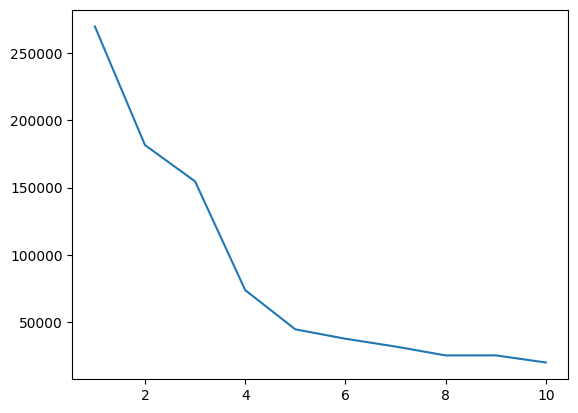

In [11]:
import matplotlib.pyplot as plt
plt.plot(range(1,11),wcss)


In [12]:
km = KMeans(n_clusters=5)
y_means = km.fit_predict(X)

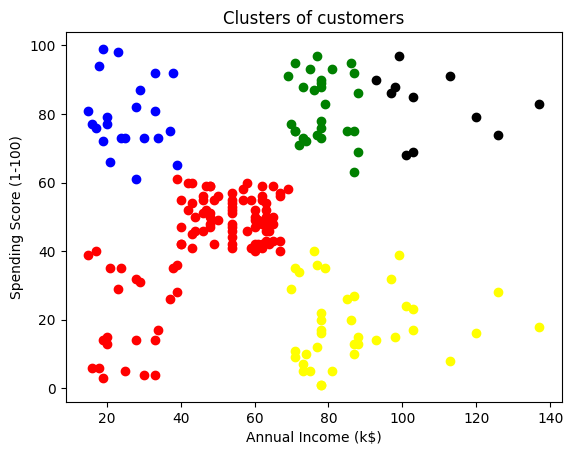

In [13]:
plt.scatter(X[y_means == 0,0],X[y_means == 0,1],color='blue')
plt.scatter(X[y_means == 1,0],X[y_means == 1,1],color='red')
plt.scatter(X[y_means == 2,0],X[y_means == 2,1],color='green')
plt.scatter(X[y_means == 3,0],X[y_means == 3,1],color='yellow')
plt.scatter(X[y_means == 4,0],X[y_means == 4,1],color='black')
plt.title('Clusters of customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show()

In [14]:

df["Target"]=y_means

In [ ]:
Clustered_df=df
Clustered_df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Target
0,1,Male,19,15,39,1
1,2,Male,21,15,81,0
2,3,Female,20,16,6,1
3,4,Female,23,16,77,0
4,5,Female,31,17,40,1


In [16]:
X=Clustered_df.iloc[:,1:5]
y=Clustered_df.iloc[:,-1]

In [17]:
X=Clustered_df.iloc[:,1:5]
y=Clustered_df.iloc[:,-1]

In [18]:
X.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


In [20]:
y.head()

0    1
1    0
2    1
3    0
4    1
Name: Target, dtype: int32

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [22]:
le=LabelEncoder()
X['Gender'] = le.fit_transform(X['Gender'])

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [24]:
sc=StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)

In [25]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

In [26]:
gbdt = GradientBoostingClassifier(n_estimators=50,random_state=2)

In [27]:
gbdt.fit(X_train,y_train)
y_pred=gbdt.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.975

In [28]:
y_pred=gbdt.predict(X_test)
y_pred

array([1, 0, 1, 3, 3, 1, 1, 3, 3, 1, 1, 3, 2, 1, 3, 2, 1, 3, 1, 1, 3, 1,
       3, 1, 1, 1, 1, 1, 2, 3, 0, 1, 1, 1, 3, 1, 2, 2, 3, 1], dtype=int32)

In [29]:
prediction = pd.DataFrame({'Original Value': y_test, 'Predicted Value': y_pred})

# Print the DataFrame
display(prediction)

,Original Value,Predicted Value
95,1,1
15,0,0
30,1,1
158,3,3
128,3,3
115,1,1
69,1,1
170,3,3
174,3,3
45,0,1
